# LoRA Weights — Top 5 Best & Worst per Bin

Load `metrics_per_image.csv` (đầu ra từ notebook inference) và hiển thị
**5 ảnh tốt nhất** và **5 ảnh tệ nhất** cho mỗi bin occlusion dựa trên metric LPIPS.

> **Metrics dùng để rank:**  
> - **LPIPS ↓** (chính) — lower is better  
> - **PSNR ↑** — higher is better  
> - **SSIM ↑** — higher is better  

---

## Cell 1 — Dependencies

In [9]:
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "diffusers>=0.27.0", "peft>=0.8.0", "accelerate>=0.26.0",
    "transformers>=4.36.0", "xformers", "scikit-image",
    "lpips", "clean-fid", "opencv-python-headless",
    "huggingface_hub", "tqdm",
], check=True)
print("Dependencies ready")

Dependencies ready


## Cell 2 — Config & Paths

In [10]:
import json, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Local paths ───────────────────────────────────────────────────────────
PROJECT_ROOT = Path('.').resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

SYNTH_DIR = PROJECT_ROOT / 'data' / 'synthetic_occ'
GT_DIR    = SYNTH_DIR / 'x_gt'
OCC_DIR   = SYNTH_DIR / 'x_occ'
MASK_DIR  = SYNTH_DIR / 'masks'
META_CSV  = SYNTH_DIR / 'metadata_synthetic_occ.csv'

LORA_OUT      = PROJECT_ROOT / 'outputs' / 'lora_weights' / 'r16_cn_ipa'
OUT_BASE      = PROJECT_ROOT / 'outputs' / 'lora_cn_ipa'
PRED_DIR      = OUT_BASE / 'x_hat'
EVAL_GT       = OUT_BASE / 'fid_gt'
EVAL_PRED     = OUT_BASE / 'fid_pred'
REPORT_DIR    = OUT_BASE / 'reports'
for d in (LORA_OUT, PRED_DIR, EVAL_GT, EVAL_PRED, REPORT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# LoRA checkpoint: best/ > final/ > root
_ckpt_candidates = [LORA_OUT / 'best', LORA_OUT / 'final']
best_ckpt = next((p for p in _ckpt_candidates if p.is_dir()), None)
if best_ckpt is None and (LORA_OUT / 'adapter_model.safetensors').is_file():
    best_ckpt = LORA_OUT
assert best_ckpt is not None, 'LoRA checkpoint khong tim thay: ' + str(LORA_OUT)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if DEVICE == 'cuda' else torch.float32

SD_MODEL_ID = 'runwayml/stable-diffusion-inpainting'
CN_MODEL_ID = 'lllyasviel/control_v11p_sd15_canny'
IP_REPO     = 'h94/IP-Adapter'
IP_WEIGHT   = 'models/ip-adapter-plus_sd15.bin'

LORA_RANK    = 16
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05

PROMPT     = 'a car, realistic, high quality, detailed, complete, no occlusion'
NEG_PROMPT = 'blurry, distorted, artifacts, extra car, duplicate'
NUM_STEPS  = 20
GUIDANCE   = 7.5

SKIP_GRID_SEARCH = True
BEST_CN          = 0.60
BEST_IP          = 0.50
CN_SCALE_GRID    = [0.15, 0.30, 0.45, 0.60, 0.75]
IP_SCALE_GRID    = [0.3, 0.5, 0.7]
GRID_SAMPLE      = 40

CANNY_LOW      = 80
CANNY_HIGH     = 150
MASK_DILATE_PX = 5

BIN_EDGES  = [(0.20, 0.40), (0.40, 0.60), (0.60, 0.80)]
BIN_LABELS = ['20-40%', '40-60%', '60-80%']
TOP_N      = 5   # so anh best / worst moi bin

RANK_BY     = 'lpips'  # ↓ lower is better
TIEBREAK_BY = 'psnr'   # ↑ higher is better

assert SYNTH_DIR.exists(), f'Dataset khong tim thay: {SYNTH_DIR}'
assert META_CSV.exists(),  f'Metadata khong tim thay: {META_CSV}'

meta = pd.read_csv(META_CSV)
meta.columns = meta.columns.str.strip().str.lower()
print(f'Dataset    : {len(meta):,} images')
print(f'Device     : {DEVICE} | dtype={DTYPE}')
print(f'LoRA       : r={LORA_RANK}, alpha={LORA_ALPHA}, ckpt={best_ckpt}')
print(f'Models     : {SD_MODEL_ID}')
print(f'ControlNet : {CN_MODEL_ID}')
print(f'META_CSV   : {META_CSV}')

Dataset    : 9,999 images
Device     : cuda | dtype=torch.float16
LoRA       : r=16, alpha=16, ckpt=D:\CS331\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r16_cn_ipa\best
Models     : runwayml/stable-diffusion-inpainting
ControlNet : lllyasviel/control_v11p_sd15_canny
META_CSV   : D:\CS331\Occluded-Object-Restoration-CarsFocus\data\synthetic_occ\metadata_synthetic_occ.csv


## Cell 3 — Load & Validate LoRA Weights

In [11]:
# best_ckpt duoc resolve o Cell 2: LORA_OUT/best > LORA_OUT/final > LORA_OUT
# ── Print weight stats ────────────────────────────────────────────────────
from safetensors import safe_open

adapter_file = best_ckpt / "adapter_model.safetensors"
assert adapter_file.is_file(), f"Thieu {adapter_file}"

print(f"LoRA checkpoint : {best_ckpt}")
print(f"Adapter file    : {adapter_file} ({adapter_file.stat().st_size / 1e6:.1f} MB)")

weight_stats = []
with safe_open(str(adapter_file), framework="pt", device="cpu") as f:
    keys = sorted(f.keys())
    print(f"Total LoRA tensors: {len(keys)}")
    for k in keys:
        t = f.get_tensor(k)
        weight_stats.append({
            "name"    : k,
            "shape"   : str(tuple(t.shape)),
            "numel"   : t.numel(),
            "mean"    : float(t.float().mean()),
            "std"     : float(t.float().std()),
            "abs_mean": float(t.float().abs().mean()),
            "max_abs" : float(t.float().abs().max()),
        })

ws_df = pd.DataFrame(weight_stats)
print("\n── Weight statistics (all tensors) ──")
print(ws_df[["name","shape","numel","mean","std","abs_mean","max_abs"]]
      .to_string(index=False))

# ── Print adapter_config.json ─────────────────────────────────────────────
cfg_file = best_ckpt / "adapter_config.json"
if cfg_file.is_file():
    with open(cfg_file) as fh:
        cfg = json.load(fh)
    print("\n── adapter_config.json ──")
    for k, v in cfg.items():
        print(f"  {k}: {v}")

LoRA checkpoint : D:\CS331\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r16_cn_ipa\best
Adapter file    : D:\CS331\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r16_cn_ipa\best\adapter_model.safetensors (27.2 MB)
Total LoRA tensors: 384

── Weight statistics (all tensors) ──
                                                                                         name            shape  numel          mean      std  abs_mean  max_abs
                            base_model.model.down_blocks.0.attentions.0.proj_in.lora_A.weight  (16, 320, 1, 1)   5120  8.871304e-04 0.063279  0.050438 0.234240
                            base_model.model.down_blocks.0.attentions.0.proj_in.lora_B.weight  (320, 16, 1, 1)   5120 -3.186550e-05 0.002796  0.002233 0.010849
                           base_model.model.down_blocks.0.attentions.0.proj_out.lora_A.weight  (16, 320, 1, 1)   5120 -1.753278e-03 0.063457  0.050606 0.258287
                           base_model.model.down_blocks.0

## Cell 4 — Top 5 / Bottom 5 LoRA Tensors by |mean weight|

Rank từng tensor LoRA theo **abs_mean** (giá trị tuyệt đối trung bình) —
tensor có abs_mean cao thường có tác động lớn nhất lên output.

TOP 5 LoRA tensors — HIGHEST |mean weight| (most influential)
                                                                                        name           shape  abs_mean      std  max_abs
  base_model.model.up_blocks.3.attentions.2.transformer_blocks.0.ff.net.0.proj.lora_A.weight       (16, 320)  0.052296 0.065728 0.246275
                            base_model.model.up_blocks.3.attentions.2.proj_out.lora_A.weight (16, 320, 1, 1)  0.052181 0.065190 0.287931
  base_model.model.up_blocks.2.attentions.2.transformer_blocks.0.ff.net.0.proj.lora_A.weight       (16, 640)  0.051902 0.065056 0.258126
base_model.model.down_blocks.0.attentions.0.transformer_blocks.0.ff.net.0.proj.lora_A.weight       (16, 320)  0.051857 0.065237 0.264519
   base_model.model.down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_k.lora_A.weight       (16, 320)  0.051768 0.065194 0.236680

BOTTOM 5 LoRA tensors — LOWEST |mean weight| (least influential)
                                                  

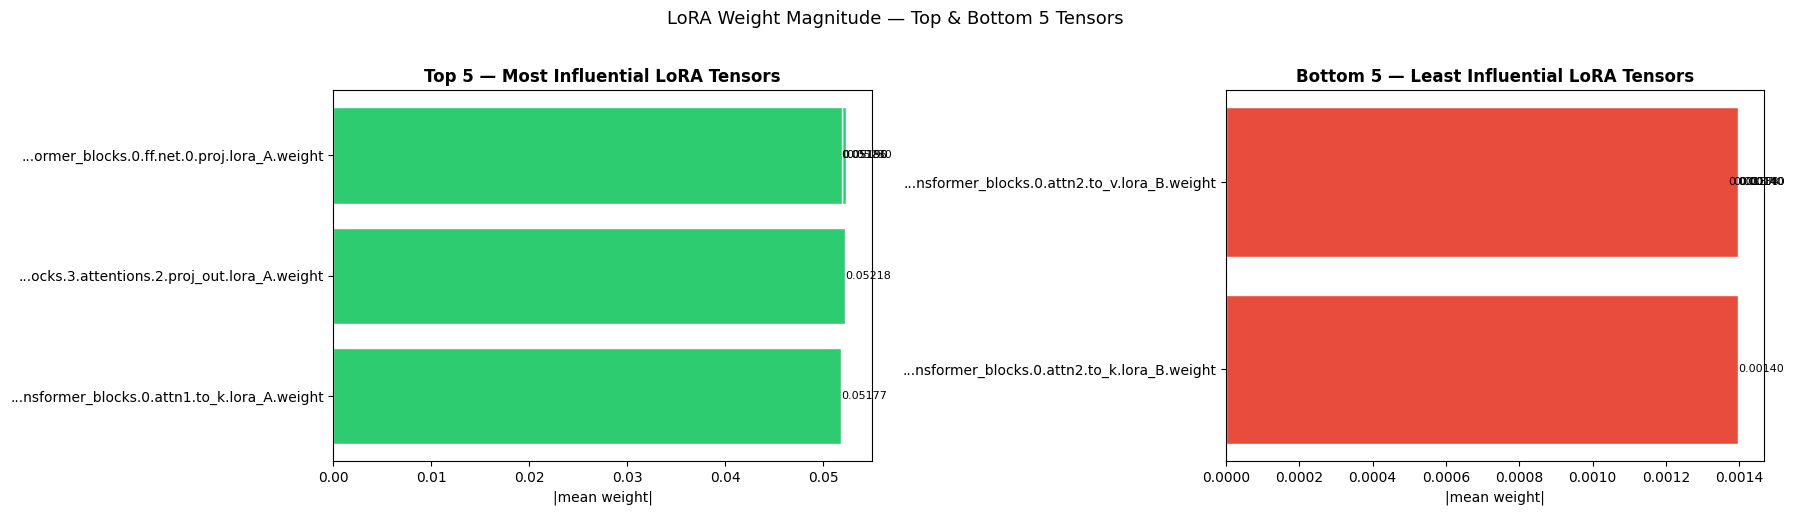

Saved: D:\CS331\Occluded-Object-Restoration-CarsFocus\outputs\lora_cn_ipa\reports\lora_weight_top_bottom5.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Rank lora_A / lora_B tensors riêng biệt để so sánh đồng nhất
ws_sorted = ws_df.sort_values("abs_mean", ascending=False).reset_index(drop=True)

top5    = ws_sorted.head(TOP_N)
bottom5 = ws_sorted.tail(TOP_N).sort_values("abs_mean")

print("=" * 80)
print(f"TOP {TOP_N} LoRA tensors — HIGHEST |mean weight| (most influential)")
print("=" * 80)
print(top5[["name", "shape", "abs_mean", "std", "max_abs"]]
      .to_string(index=False))

print()
print("=" * 80)
print(f"BOTTOM {TOP_N} LoRA tensors — LOWEST |mean weight| (least influential)")
print("=" * 80)
print(bottom5[["name", "shape", "abs_mean", "std", "max_abs"]]
      .to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

def short_name(n, maxlen=45):
    return n if len(n) <= maxlen else "..." + n[-maxlen+3:]

# Top 5
ax = axes[0]
names_t = [short_name(n) for n in top5["name"]]
bars = ax.barh(names_t, top5["abs_mean"], color="#2ecc71", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("|mean weight|")
ax.set_title(f"Top {TOP_N} — Most Influential LoRA Tensors", fontweight="bold")
for bar, v in zip(bars, top5["abs_mean"]):
    ax.text(v + 1e-5, bar.get_y() + bar.get_height()/2,
            f"{v:.5f}", va="center", fontsize=8)

# Bottom 5
ax = axes[1]
names_b = [short_name(n) for n in bottom5["name"]]
bars = ax.barh(names_b, bottom5["abs_mean"], color="#e74c3c", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("|mean weight|")
ax.set_title(f"Bottom {TOP_N} — Least Influential LoRA Tensors", fontweight="bold")
for bar, v in zip(bars, bottom5["abs_mean"]):
    ax.text(v + 1e-6, bar.get_y() + bar.get_height()/2,
            f"{v:.5f}", va="center", fontsize=8)

plt.suptitle("LoRA Weight Magnitude — Top & Bottom 5 Tensors", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(REPORT_DIR / "lora_weight_top_bottom5.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", REPORT_DIR / "lora_weight_top_bottom5.png")

## Cell 5 — Load Pipeline (SD1.5 + ControlNet + IP-Adapter + LoRA)

In [13]:
import cv2
from PIL import Image
from diffusers import (
    ControlNetModel,
    DPMSolverMultistepScheduler,
    StableDiffusionControlNetInpaintPipeline,
)
from peft import PeftModel

print("Loading ControlNet ...")
controlnet = ControlNetModel.from_pretrained(CN_MODEL_ID, torch_dtype=DTYPE)

print("Loading SD1.5 Inpainting ...")
pipe = StableDiffusionControlNetInpaintPipeline.from_pretrained(
    SD_MODEL_ID, controlnet=controlnet, torch_dtype=DTYPE,
    safety_checker=None, requires_safety_checker=False,
)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

print(f"Merging LoRA from {best_ckpt} ...")
pipe.unet = PeftModel.from_pretrained(pipe.unet, str(best_ckpt))
pipe.unet = pipe.unet.merge_and_unload()
print("LoRA merged into UNet OK")

pipe = pipe.to(DEVICE)
xformers_ok = False
try:
    pipe.enable_xformers_memory_efficient_attention(); xformers_ok = True
    print("xFormers: OK")
except Exception:
    pipe.enable_attention_slicing("auto")
    print("xFormers: fallback → attention slicing")
pipe.vae.enable_slicing()

use_ip = False
try:
    pipe.load_ip_adapter(IP_REPO, subfolder="models", weight_name=IP_WEIGHT)
    use_ip = True; print("IP-Adapter: OK")
except Exception as e:
    print("IP-Adapter: FAILED", e)

print(f"Pipeline ready | LoRA r={LORA_RANK} | IP={use_ip} | xFormers={xformers_ok}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} | {p.total_memory/1e9:.1f} GB")

c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
    ^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'triton'


Loading ControlNet ...
Loading SD1.5 Inpainting ...


text_encoder\model.safetensors not found
Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]An error occurred while trying to fetch C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  50%|█████     | 3/6 [00:08<00:06,  2.24s/it]c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this 

Merging LoRA from D:\CS331\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r16_cn_ipa\best ...
LoRA merged into UNet OK
xFormers: OK
IP-Adapter: FAILED h94/IP-Adapter does not appear to have a file named models/ip-adapter-plus_sd15.bin.
Pipeline ready | LoRA r=16 | IP=False | xFormers=True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU | 6.4 GB


## Cell 6 — Inference & Metric Helpers

In [14]:
import lpips as lpips_lib
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

lpips_model = lpips_lib.LPIPS(net="alex").to(DEVICE).eval()


def extract_canny_masked(img_pil, mask_pil, low=CANNY_LOW, high=CANNY_HIGH,
                          dilate_px=MASK_DILATE_PX):
    img   = np.array(img_pil.convert("RGB"))
    gray  = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, low, high)
    mask_np = np.array(mask_pil.convert("L"))
    if dilate_px > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                (dilate_px*2+1, dilate_px*2+1))
        mask_np = cv2.dilate(mask_np, k, iterations=1)
    edges[mask_np > 127] = 0
    return Image.fromarray(np.stack([edges]*3, axis=2))


def extract_visible_patch(img_pil, mask_pil):
    img  = np.array(img_pil.convert("RGB"))
    mask = np.array(mask_pil.convert("L"))
    vis  = img.copy()
    vis[mask > 127] = 128
    return Image.fromarray(vis)


def inpaint(image, mask, prompt, cn_scale=BEST_CN, ip_scale=BEST_IP, seed=SEED):
    canny   = extract_canny_masked(image, mask)
    gen     = torch.Generator(device=DEVICE).manual_seed(seed)
    vis_ref = extract_visible_patch(image, mask)
    kwargs  = dict(
        prompt=prompt, negative_prompt=NEG_PROMPT,
        image=image, control_image=canny, mask_image=mask,
        num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE,
        controlnet_conditioning_scale=cn_scale, generator=gen,
    )
    if use_ip:
        pipe.set_ip_adapter_scale(ip_scale)
        kwargs["ip_adapter_image"] = vis_ref
    ctx = torch.autocast("cuda") if DEVICE == "cuda" else torch.no_grad()
    with ctx:
        result = pipe(**kwargs).images[0]
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return result


# ── Metric functions ──────────────────────────────────────────────────────
def pixel_l1(gt, pred, mask01):
    g, p = gt.astype(np.float64)/255, pred.astype(np.float64)/255
    m = mask01.astype(bool)
    return float(np.mean(np.abs(g[m]-p[m]))) if m.sum()>0 else float(np.mean(np.abs(g-p)))


def pixel_l2(gt, pred, mask01):
    g, p = gt.astype(np.float64)/255, pred.astype(np.float64)/255
    m = mask01.astype(bool)
    return float(np.mean((g[m]-p[m])**2)) if m.sum()>0 else float(np.mean((g-p)**2))


def masked_psnr(gt, pred, mask01):
    m = mask01.astype(bool)
    if m.sum() == 0: return float(psnr_fn(gt, pred, data_range=255))
    mse = np.mean((gt[m].astype(np.float64) - pred[m].astype(np.float64))**2)
    return 100.0 if mse == 0 else float(10 * np.log10(255**2 / mse))


def masked_ssim(gt, pred, mask01):
    return float(ssim_fn(gt, pred, channel_axis=2, data_range=255))


def masked_lpips(gt_np, pred_np, mask01):
    def to_t(a):
        return torch.from_numpy(a).float().permute(2,0,1).unsqueeze(0).to(DEVICE)/127.5 - 1
    with torch.no_grad():
        v = lpips_model(to_t(gt_np), to_t(pred_np)).item()
    return float(v)


print("Helpers ready.")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\lpips\weights\v0.1\alex.pth
Helpers ready.


## Cell 7 — Build Evaluation Set (giống notebook 08)

In [15]:
meta = pd.read_csv(META_CSV)
meta.columns = meta.columns.str.strip().str.lower()
if "stem" not in meta.columns and "filename" in meta.columns:
    meta["stem"] = meta["filename"].str.replace(r"\.[^.]+$", "", regex=True)

def mask_path_for_row(row):
    m = row.get("mask")
    if m is None or (isinstance(m, float) and np.isnan(m)):
        return f"{row['stem']}.png"
    s = str(m).strip()
    return s if s else f"{row['stem']}.png"

if "mask" not in meta.columns:
    meta["mask"] = [mask_path_for_row(r) for _, r in meta.iterrows()]
else:
    meta["mask"] = [
        mask_path_for_row(meta.loc[i])
        if (pd.isna(meta.loc[i,"mask"]) or str(meta.loc[i,"mask"]).strip()=="")
        else str(meta.loc[i,"mask"]).strip()
        for i in meta.index
    ]

meta_full = meta.reset_index(drop=True)
assert "occlusion_ratio" in meta_full.columns

_per_bin = 2000 // len(BIN_EDGES)
_bin_dfs = []
for lo, hi in BIN_EDGES:
    sub = meta_full[(meta_full["occlusion_ratio"]>=lo)&(meta_full["occlusion_ratio"]<hi)]
    _bin_dfs.append(sub.sample(min(_per_bin, len(sub)), random_state=SEED))
eval_df = pd.concat(_bin_dfs).sample(frac=1, random_state=SEED).reset_index(drop=True)

def _bin_label(r):
    for (lo, hi), lbl in zip(BIN_EDGES, BIN_LABELS):
        if lo <= r < hi: return lbl
    return "?"

eval_df["bin_label"] = eval_df["occlusion_ratio"].map(_bin_label)

print(f"Total eval: {len(eval_df)} images")
for (lo,hi),lbl in zip(BIN_EDGES, BIN_LABELS):
    n = len(eval_df[(eval_df["occlusion_ratio"]>=lo)&(eval_df["occlusion_ratio"]<hi)])
    print(f"  {lbl}: {n} images")

Total eval: 1998 images
  20-40%: 666 images
  40-60%: 666 images
  60-80%: 666 images


## Cell 8 — Inference + Per-Image Metrics

In [16]:
import time
from tqdm.auto import tqdm

print(f"Inference: {len(eval_df)} images | cn={BEST_CN} ip={BEST_IP} steps={NUM_STEPS}")
metric_rows = []
t0 = time.time()

for _, r in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Infer+Eval"):
    occ  = Image.open(OCC_DIR  / r["x_occ"]).convert("RGB").resize((512,512))
    msk  = Image.open(MASK_DIR / r["mask"]).convert("L").resize((512,512))
    gt   = Image.open(GT_DIR   / r["x_gt"]).convert("RGB").resize((512,512))
    pred = inpaint(occ, msk, PROMPT)

    fname = f"{r['stem']}.png"
    pred.save(PRED_DIR / fname)
    gt.save(EVAL_GT / fname)
    pred.save(EVAL_PRED / fname)

    gt_np   = np.array(gt)
    pr_np   = np.array(pred)
    mk_np   = np.array(msk)
    mk01    = (mk_np > 127).astype(np.uint8)

    metric_rows.append({
        "stem"           : r["stem"],
        "x_gt"           : r["x_gt"],
        "x_occ"          : r["x_occ"],
        "mask"           : r["mask"],
        "occlusion_ratio": float(r["occlusion_ratio"]),
        "bin_label"      : r["bin_label"],
        "pred"           : fname,
        "l1"   : pixel_l1(gt_np, pr_np, mk01),
        "l2"   : pixel_l2(gt_np, pr_np, mk01),
        "psnr" : masked_psnr(gt_np, pr_np, mk01),
        "ssim" : masked_ssim(gt_np, pr_np, mk01),
        "lpips": masked_lpips(gt_np, pr_np, mk01),
    })

metric_df = pd.DataFrame(metric_rows)
metric_df.to_csv(REPORT_DIR / "metrics_per_image.csv", index=False)

elapsed = time.time() - t0
print(f"Done: {len(metric_df)} images | {elapsed/60:.1f} min | {elapsed/max(len(metric_df),1):.1f}s/img")
print(metric_df[["l1","l2","psnr","ssim","lpips"]].describe().round(4))

Inference: 1998 images | cn=0.6 ip=0.5 steps=20


Infer+Eval: 100%|██████████| 1998/1998 [3:48:48<00:00,  6.87s/it]


Done: 1998 images | 228.8 min | 6.9s/img
              l1         l2       psnr       ssim      lpips
count  1998.0000  1998.0000  1998.0000  1998.0000  1998.0000
mean      0.1105     0.0370    15.0592     0.7780     0.1316
std       0.0398     0.0223     2.7255     0.0800     0.0499
min       0.0066     0.0001     7.1529     0.4760     0.0217
25%       0.0834     0.0221    13.3753     0.7290     0.0950
50%       0.1054     0.0325    14.8828     0.7852     0.1272
75%       0.1336     0.0460    16.5464     0.8363     0.1637
max       0.3318     0.1926    41.9017     0.9711     0.3415


## Cell 9 — Top 5 Best & Worst per Bin

Rank theo **LPIPS ↓** (lower = better).  
Hiển thị ảnh: `x_occ` | `mask` | `pred` | `x_gt` cho mỗi sample.


BIN: 20-40%  (666 images)

TOP 5 BEST (LPIPS ↓):
                    stem  occlusion_ratio    lpips      psnr     ssim       l1       l2
 cars_test_07317_b0_2669           0.3378 0.021735 39.024234 0.971074 0.010229 0.000125
cars_train_07837_b0_1448           0.2140 0.025534 24.249052 0.954164 0.023824 0.003759
cars_train_04905_b0_2620           0.2773 0.026700 19.046969 0.955277 0.042001 0.012454
 cars_test_06351_b0_1627           0.2076 0.030724 24.903369 0.930847 0.028030 0.003233
cars_train_03994_b0_1111           0.2042 0.033901 15.805586 0.910613 0.075370 0.026269

TOP 5 WORST (LPIPS ↓):
                    stem  occlusion_ratio    lpips      psnr     ssim       l1       l2
 cars_test_06051_b0_1633           0.3787 0.268057 12.751024 0.688681 0.153982 0.053076
 cars_test_04139_b0_1870           0.3633 0.198508 15.833883 0.542215 0.108142 0.026098
cars_train_03641_b0_0622           0.3961 0.195559 12.506667 0.737178 0.155516 0.056148
cars_train_02996_b0_1466           0.3849 0.18

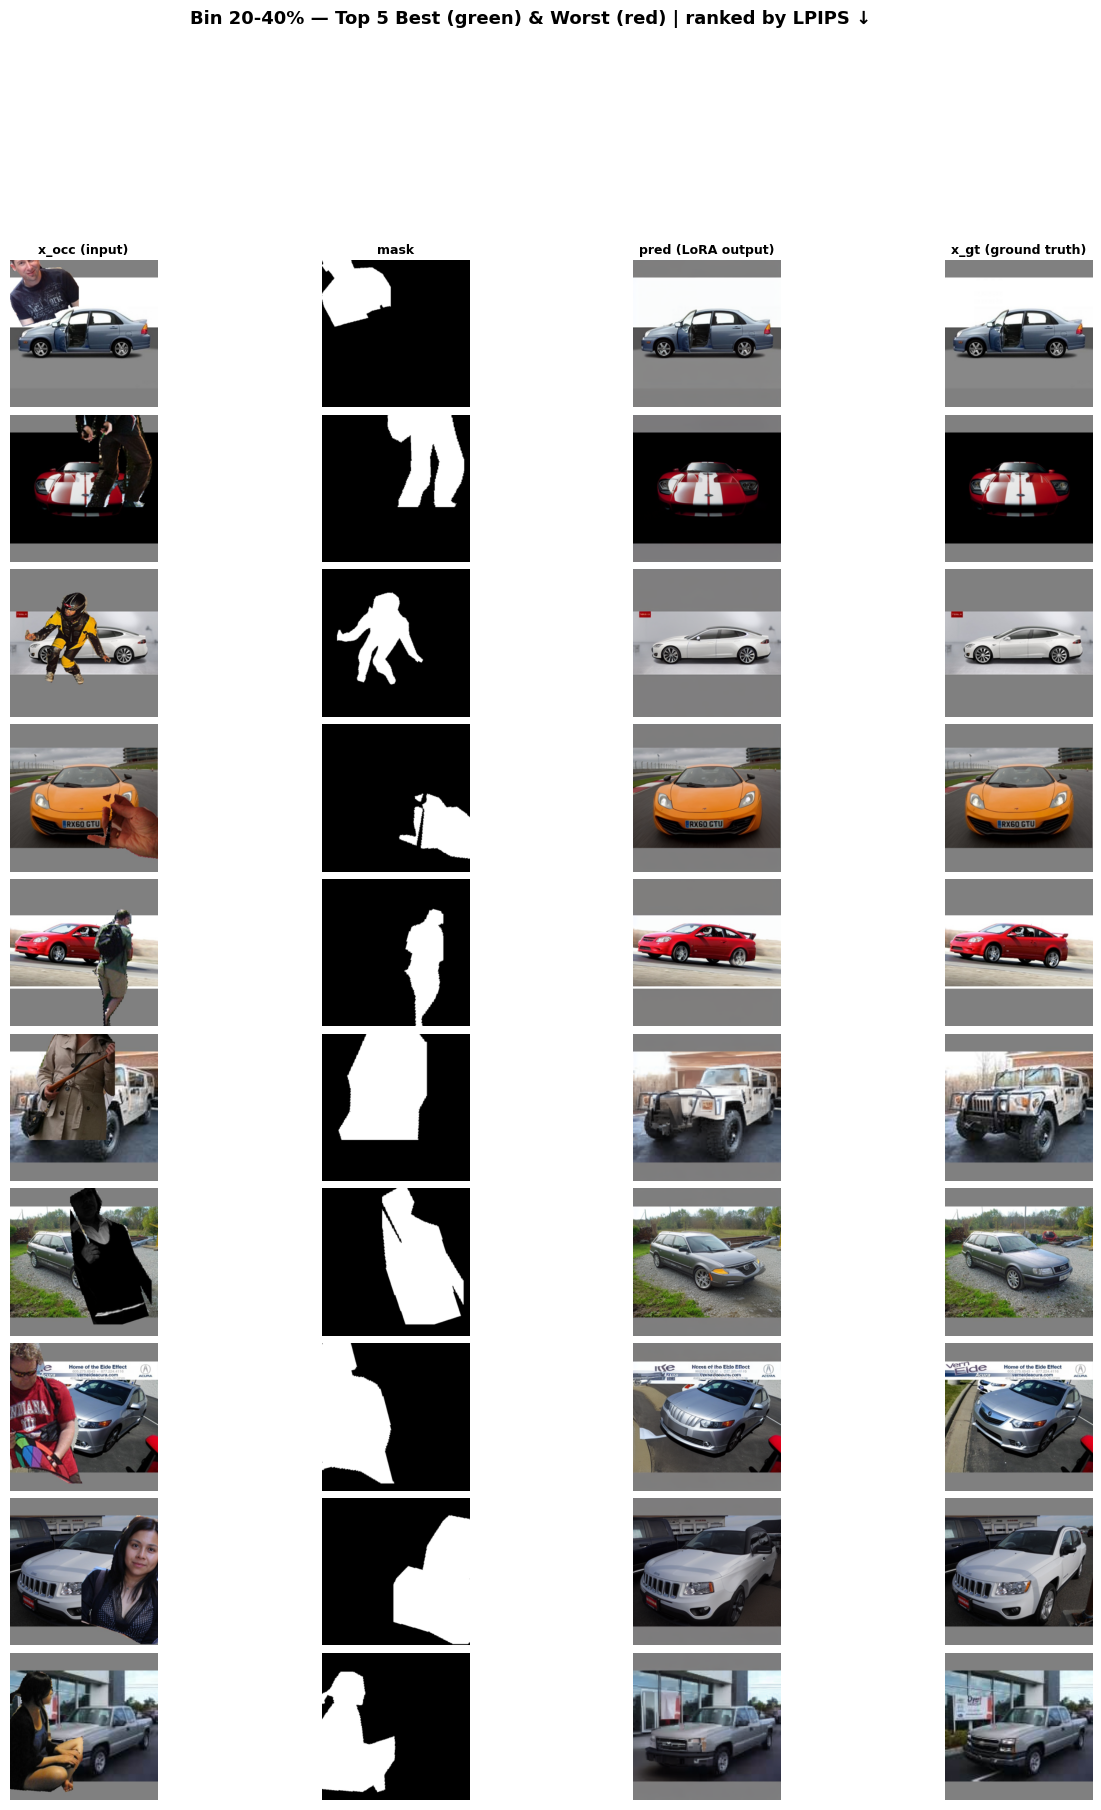

Saved: D:\CS331\Occluded-Object-Restoration-CarsFocus\outputs\lora_cn_ipa\reports\top5_best_worst_2040pct.png

BIN: 40-60%  (666 images)

TOP 5 BEST (LPIPS ↓):
                    stem  occlusion_ratio    lpips      psnr     ssim       l1       l2
 cars_test_07895_b1_1466           0.4314 0.040307 15.803346 0.929389 0.061351 0.026282
cars_train_05842_b1_1491           0.4647 0.044751 24.178348 0.861331 0.026359 0.003821
 cars_test_04317_b1_0388           0.4470 0.047483 17.578001 0.896711 0.073084 0.017466
cars_train_01744_b1_2121           0.4712 0.047544 15.128596 0.937569 0.086234 0.030700
 cars_test_01556_b1_0332           0.4717 0.047668 20.179476 0.910094 0.052907 0.009595

TOP 5 WORST (LPIPS ↓):
                    stem  occlusion_ratio    lpips      psnr     ssim       l1       l2
cars_train_07650_b1_1227           0.5195 0.247078 11.960034 0.630130 0.165479 0.063679
cars_train_01563_b1_0109           0.5494 0.245218 12.647612 0.647975 0.153641 0.054355
cars_train_07666_b1_1796

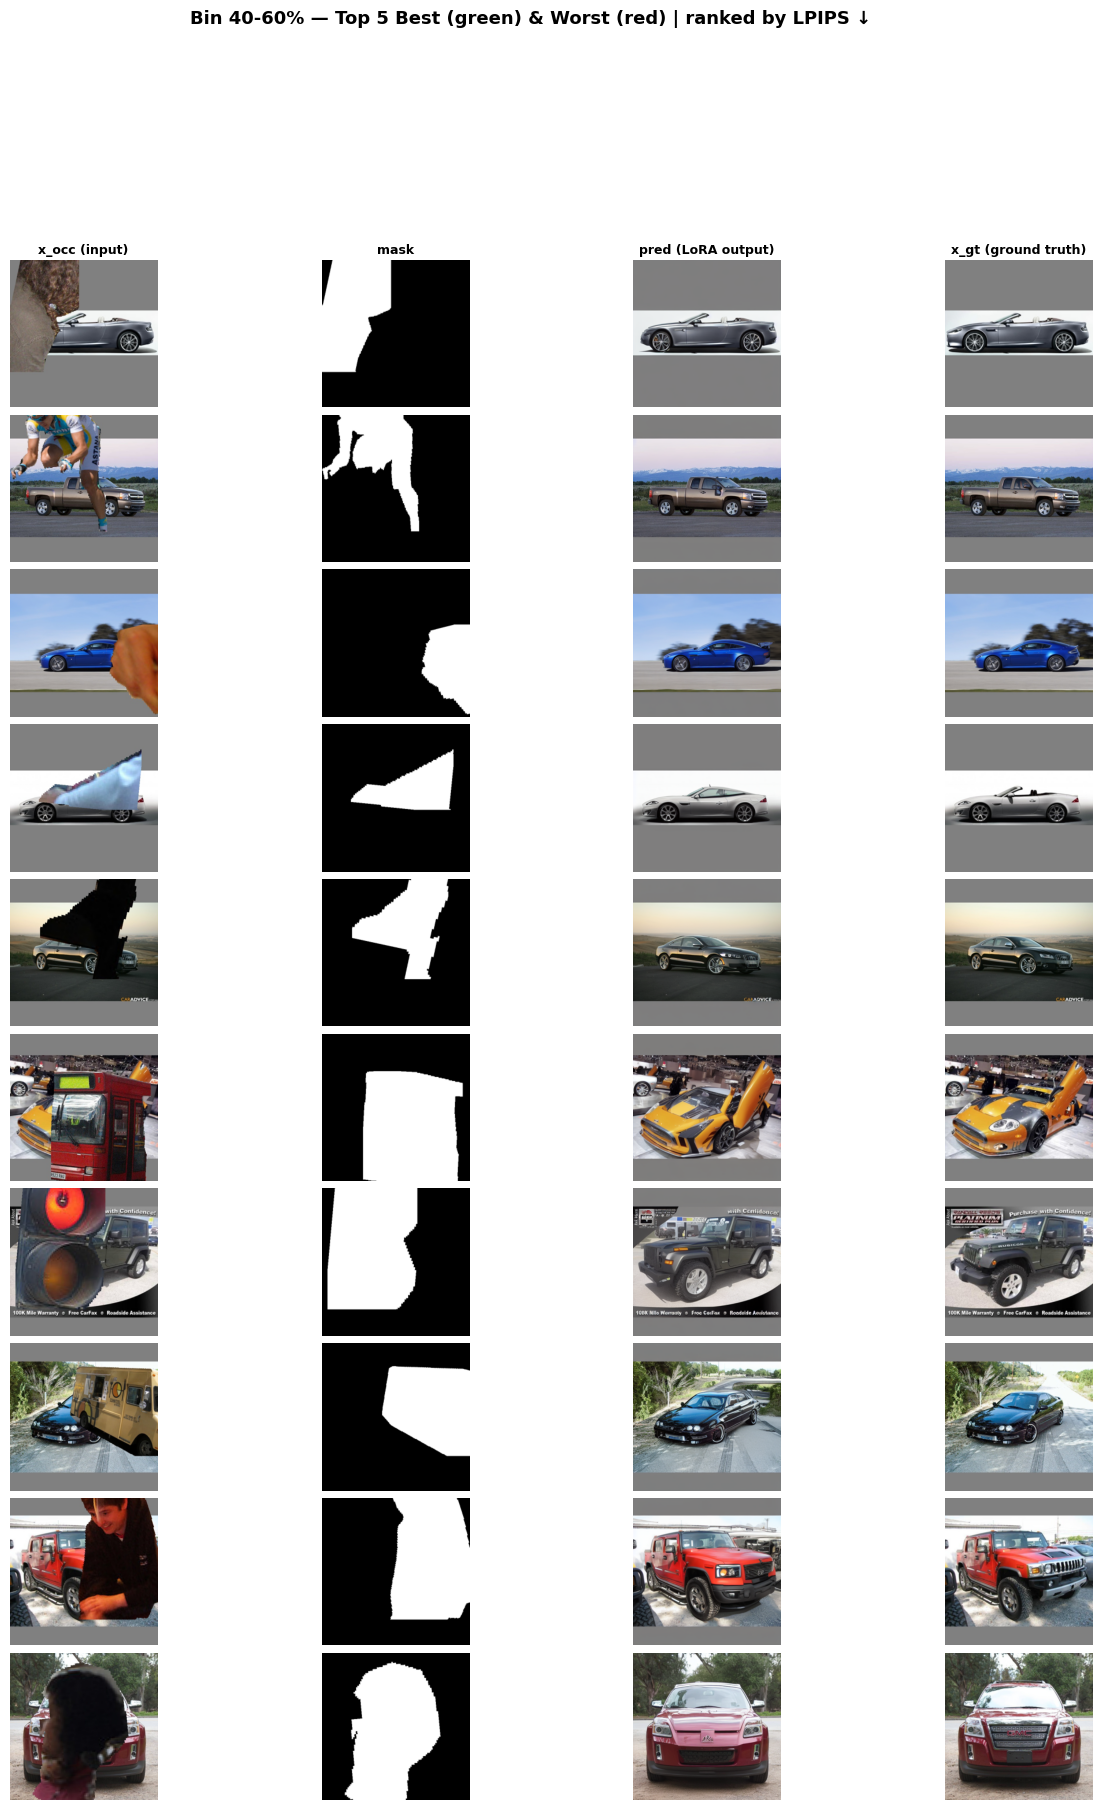

Saved: D:\CS331\Occluded-Object-Restoration-CarsFocus\outputs\lora_cn_ipa\reports\top5_best_worst_4060pct.png

BIN: 60-80%  (666 images)

TOP 5 BEST (LPIPS ↓):
                    stem  occlusion_ratio    lpips      psnr     ssim       l1       l2
 cars_test_04995_b2_2274           0.6122 0.023537 41.901750 0.951968 0.006553 0.000065
 cars_test_03152_b2_0496           0.6234 0.030028 16.568306 0.950672 0.052453 0.022038
 cars_test_06418_b2_0158           0.6247 0.049860 14.801120 0.902454 0.084609 0.033105
cars_train_06529_b2_0275           0.6804 0.054661 17.978521 0.905762 0.058240 0.015928
cars_train_07713_b2_1591           0.7275 0.057001 20.277837 0.926087 0.043192 0.009380

TOP 5 WORST (LPIPS ↓):
                    stem  occlusion_ratio    lpips      psnr     ssim       l1       l2
cars_train_06502_b2_1958           0.7496 0.341453 13.756508 0.576107 0.145338 0.042107
cars_train_05248_b2_2370           0.6186 0.326264 11.025006 0.522026 0.199192 0.078977
cars_train_05205_b2_1790

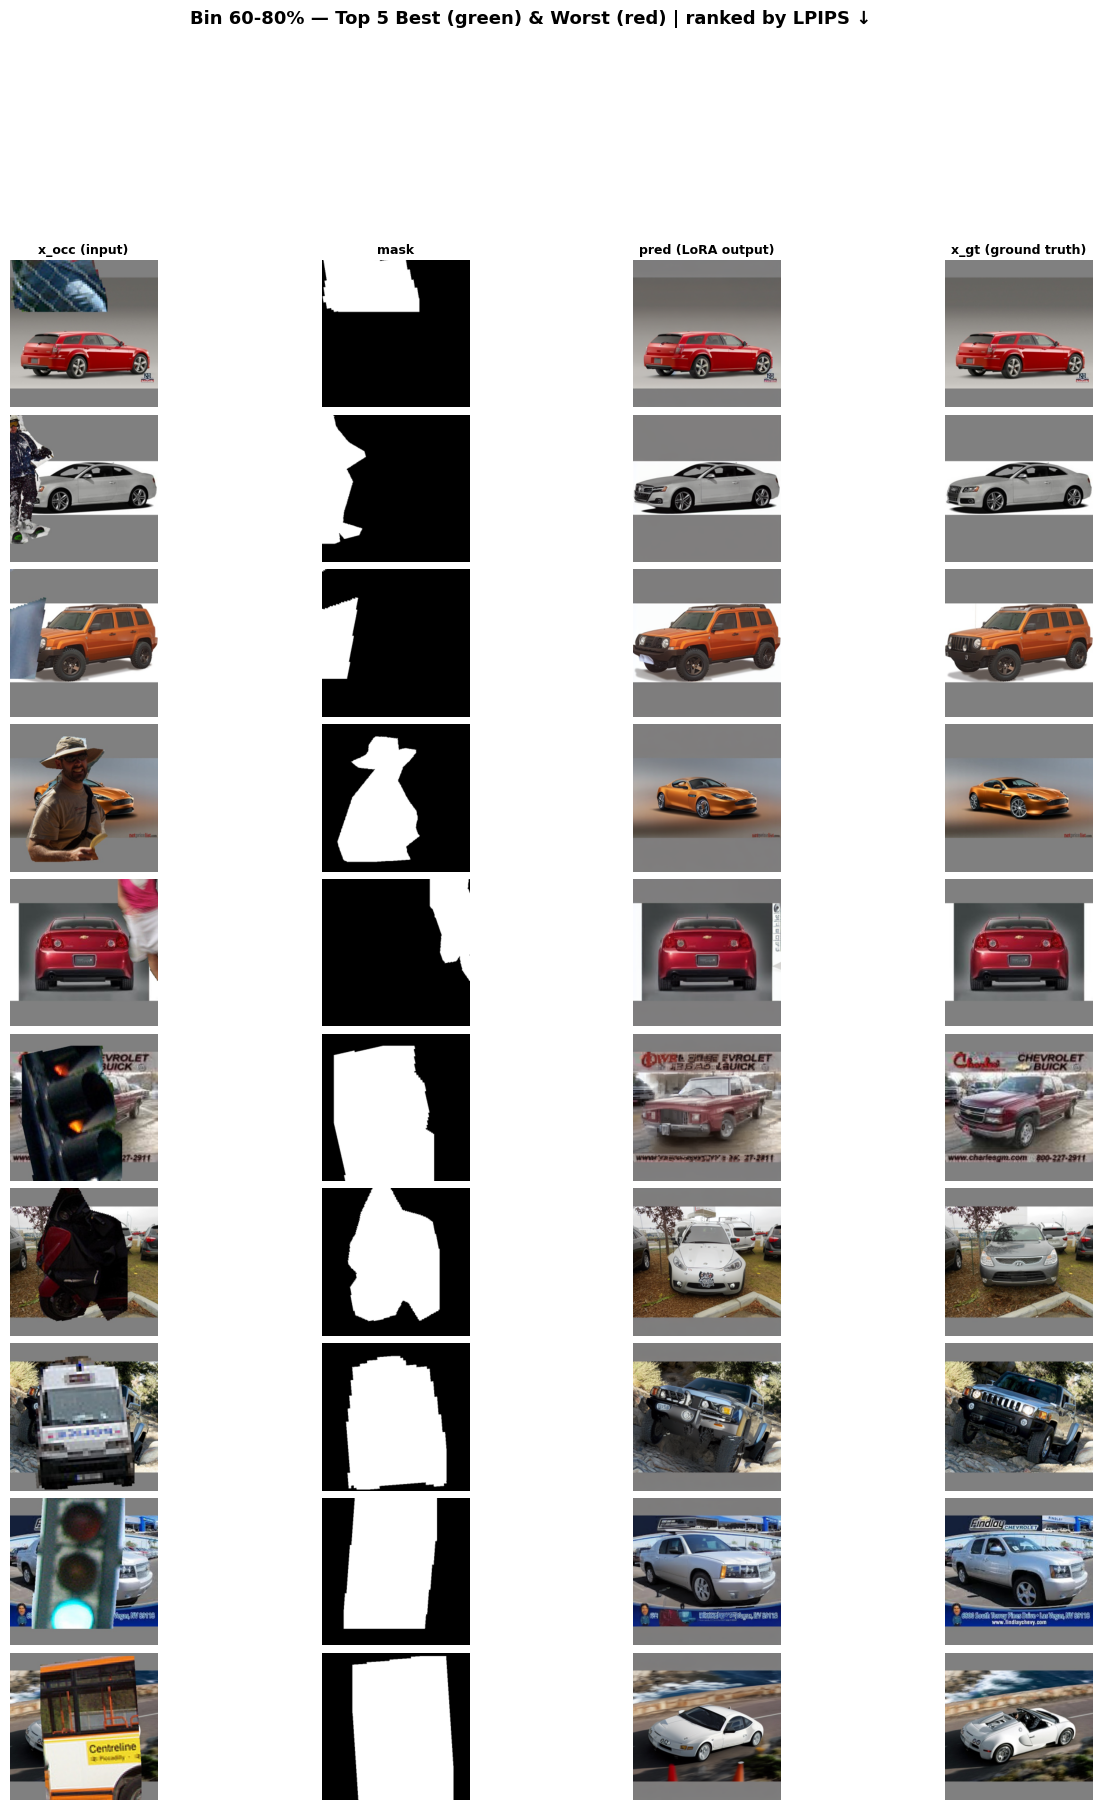

Saved: D:\CS331\Occluded-Object-Restoration-CarsFocus\outputs\lora_cn_ipa\reports\top5_best_worst_6080pct.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ALL_METRICS = ["l1", "l2", "psnr", "ssim", "lpips"]


def get_top_bottom(sub_df, metric=RANK_BY, n=TOP_N, ascending_is_better=True):
    """ascending_is_better=True  → best = smallest (L1/L2/LPIPS)
       ascending_is_better=False → best = largest  (PSNR/SSIM)"""
    sorted_df = sub_df.sort_values(metric, ascending=ascending_is_better)
    best    = sorted_df.head(n)
    worst   = sorted_df.tail(n).iloc[::-1]  # worst-first
    return best, worst


def load_img(path):
    try: return Image.open(path).convert("RGB").resize((256,256))
    except: return Image.new("RGB", (256,256), (50,50,50))


def show_bin_results(bin_df, bin_label, metric=RANK_BY, ascending_is_better=True, n=TOP_N):
    best, worst = get_top_bottom(bin_df, metric, n, ascending_is_better)

    fig, axes = plt.subplots(
        2 * n, 4,
        figsize=(16, 4 * n),
        gridspec_kw={"hspace": 0.05, "wspace": 0.02},
    )

    col_titles = ["x_occ (input)", "mask", "pred (LoRA output)", "x_gt (ground truth)"]

    for group_idx, (group_df, group_name, row_color) in enumerate([
        (best,  f"BEST  {n}", "#d4edda"),
        (worst, f"WORST {n}", "#f8d7da"),
    ]):
        for rank_idx, (_, row) in enumerate(group_df.iterrows()):
            ax_row = group_idx * n + rank_idx

            imgs = [
                load_img(OCC_DIR  / row["x_occ"]),
                load_img(MASK_DIR / row["mask"]),
                load_img(PRED_DIR / row["pred"]),
                load_img(GT_DIR   / row["x_gt"]),
            ]

            for col_idx, (ax, img) in enumerate(zip(axes[ax_row], imgs)):
                ax.imshow(img, cmap="gray" if col_idx == 1 else None)
                ax.axis("off")
                # Column headers only on first row
                if ax_row == 0:
                    ax.set_title(col_titles[col_idx], fontsize=9, fontweight="bold", pad=4)

            # Row label with metrics
            label = (
                f"{group_name} #{rank_idx+1}\n"
                f"LPIPS={row['lpips']:.4f}\n"
                f"PSNR={row['psnr']:.2f}\n"
                f"SSIM={row['ssim']:.4f}\n"
                f"occ={row['occlusion_ratio']:.2f}"
            )
            axes[ax_row, 0].set_ylabel(label, fontsize=7.5, rotation=0,
                                        labelpad=75, va="center")

            # Background tint
            for ax in axes[ax_row]:
                ax.set_facecolor(row_color)

    fig.suptitle(
        f"Bin {bin_label} — Top {n} Best (green) & Worst (red) | ranked by {metric.upper()} ↓",
        fontsize=13, fontweight="bold", y=1.005,
    )

    out_png = REPORT_DIR / f"top{n}_best_worst_{bin_label.replace('-','').replace('%','pct')}.png"
    plt.savefig(out_png, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_png}")


# ── Run for each bin ──────────────────────────────────────────────────────
for (lo, hi), lbl in zip(BIN_EDGES, BIN_LABELS):
    bin_df = metric_df[(metric_df["occlusion_ratio"]>=lo)&(metric_df["occlusion_ratio"]<hi)]
    print(f"\n{'='*70}")
    print(f"BIN: {lbl}  ({len(bin_df)} images)")
    print(f"{'='*70}")

    best, worst = get_top_bottom(bin_df, RANK_BY, TOP_N, ascending_is_better=True)

    print(f"\nTOP {TOP_N} BEST (LPIPS ↓):")
    print(best[["stem","occlusion_ratio","lpips","psnr","ssim","l1","l2"]]
          .to_string(index=False))

    print(f"\nTOP {TOP_N} WORST (LPIPS ↓):")
    print(worst[["stem","occlusion_ratio","lpips","psnr","ssim","l1","l2"]]
          .to_string(index=False))

    show_bin_results(bin_df, lbl)

## Cell 10 — Summary Table per Bin + Overall

SUMMARY — SD1.5 + LoRA r=16 + ControlNet + IP-Adapter
cn=0.6  ip=0.5  steps=20
    bin    n     l1     l2    psnr   ssim  lpips
overall 1998 0.1105 0.0370 15.0592 0.7780 0.1316
 20-40%  666 0.0981 0.0309 16.0328 0.8170 0.0955
 40-60%  666 0.1109 0.0367 14.9311 0.7724 0.1344
 60-80%  666 0.1227 0.0435 14.2137 0.7447 0.1648


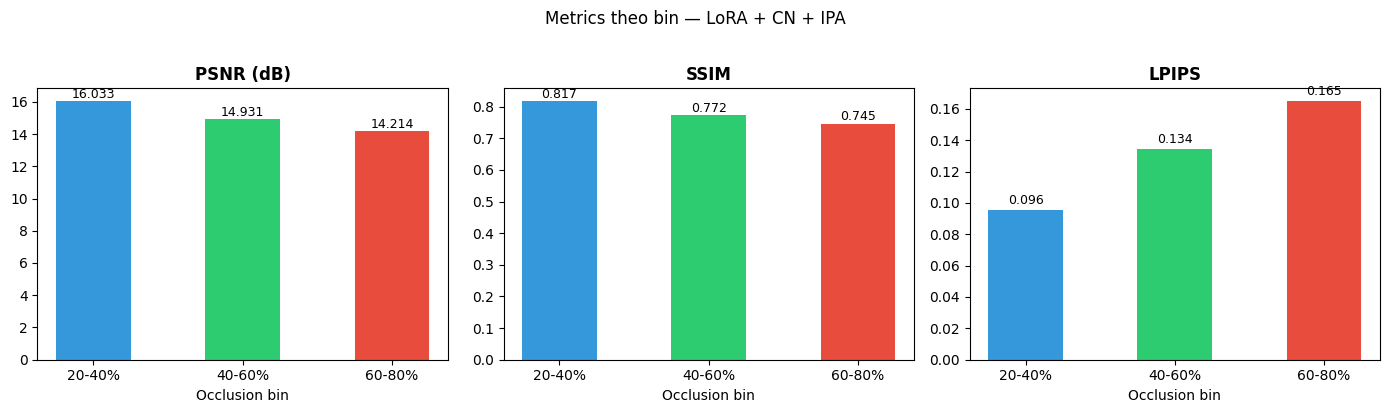

All reports saved to: D:\CS331\Occluded-Object-Restoration-CarsFocus\outputs\lora_cn_ipa\reports


In [18]:
rows = []
for (lo,hi),lbl in zip(BIN_EDGES, BIN_LABELS):
    sub = metric_df[(metric_df["occlusion_ratio"]>=lo)&(metric_df["occlusion_ratio"]<hi)]
    if len(sub)==0: continue
    rows.append({"bin":lbl,"n":len(sub),
                 **{m:round(float(sub[m].mean()),4) for m in ALL_METRICS}})

overall = {"bin":"overall","n":len(metric_df),
           **{m:round(float(metric_df[m].mean()),4) for m in ALL_METRICS}}
summary_df = pd.DataFrame([overall]+rows)

print("="*80)
print(f"SUMMARY — SD1.5 + LoRA r={LORA_RANK} + ControlNet + IP-Adapter")
print(f"cn={BEST_CN}  ip={BEST_IP}  steps={NUM_STEPS}")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

summary_df.to_csv(REPORT_DIR/"summary_table.csv", index=False)

# ── Bar chart PSNR / SSIM / LPIPS ─────────────────────────────────────────
plot_df = summary_df[summary_df["bin"]!="overall"].copy()
fig, axes = plt.subplots(1, 3, figsize=(14,4))
colors = ["#3498db","#2ecc71","#e74c3c"]
for ax,(col,ylabel) in zip(axes,[("psnr","PSNR (dB)"),("ssim","SSIM"),("lpips","LPIPS")]):
    sub = plot_df.dropna(subset=[col])
    bars = ax.bar(sub["bin"], sub[col], color=colors[:len(sub)], width=0.5)
    ax.set_title(ylabel, fontweight="bold")
    ax.set_xlabel("Occlusion bin")
    for bar,v in zip(bars, sub[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.suptitle("Metrics theo bin — LoRA + CN + IPA", y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR/"summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("All reports saved to:", REPORT_DIR)